# 01. Generate empirical train from scratch

This is the expensive simulation notebook.  It constructs the synthetic incompressible Gaussian--Holder flow, advects volume-filled tracer clouds, fits the MEE, computes the ellipsoid-averaged gradient, and writes `empirical_train_mavg_out_v10.npz`.

This is the actual data-generating provenance layer.  Running it may take minutes on a laptop.  The resulting NPZ is also bundled so that later notebooks can be run immediately.


# Empirical baseline: MEE with ellipsoid-averaged gradient

This notebook keeps only the empirical target used in the cleaned notes:

$$
(M,g)=(M^{(\mathrm{avg,out})},g^{(\mathrm{out})}).
$$

The cloud is volume-filled; $g$ is the minimum-volume enclosing ellipsoid (MEE); $M$ is the closed-form spatial average of the instantaneous gradient over that ellipsoid.  The notebook no longer compares to secondary gradient definitions or to the inner ellipsoid.

Empirical tasks:

1. shape saturation: $\langle\sigma\mid r\rangle$, $P(\sigma\mid r)$, KS distances;
2. corrected strain--vorticity balance: $\chi=\mathrm{var}(\omega)/(\mathrm{var}(s_+)+\mathrm{var}(s_\times))$, baseline $1$;
3. $\langle |M|^2\rangle$ scaling, reported honestly even if steeper than $r^{-4/3}$;
4. rescaled-component skewness/kurtosis;
5. alignment and lifted-shape diagnostics for later generator calibration.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy import stats
from scipy.spatial import ConvexHull
from scipy.special import j1

PI = np.pi
TWOPI = 2.0 * PI

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


## 1. Flow + MEE machinery

The code below retains only the volume-filled cloud, the outer L"owner--John ellipsoid, and the ellipsoid-averaged gradient.

In [2]:
def make_wavevectors(K_max):
    ks = []
    for kx in range(-K_max, K_max + 1):
        for ky in range(-K_max, K_max + 1):
            if kx == 0 and ky == 0:
                continue
            if kx * kx + ky * ky > K_max * K_max:
                continue
            if kx > 0 or (kx == 0 and ky > 0):
                ks.append((kx, ky))
    k_arr = np.array(ks, dtype=float)
    k_mag = np.sqrt((k_arr ** 2).sum(axis=1))
    perp = np.column_stack([-k_arr[:, 1], k_arr[:, 0]])
    perp_norm = perp / k_mag[:, None]
    return k_arr, k_mag, perp_norm


class SinOnlyFlow:
    def __init__(self, K_max, zeta, dt, tau0=1.0, grad_rms=5.0):
        self.K_max, self.zeta, self.dt = K_max, zeta, dt
        self.k_arr, self.k_mag, self.perp_norm = make_wavevectors(K_max)
        shape = 1.0 / self.k_mag ** (2 * zeta + 2)
        C = grad_rms ** 2 / (2.0 * np.sum(self.k_mag ** (-2 * zeta)))
        self.E_k = C * shape
        self.tau_k = tau0 / self.k_mag ** (1 - zeta)
        self.exp_decay = np.exp(-dt / self.tau_k)
        self.noise_amp = np.sqrt(self.E_k * (1.0 - self.exp_decay ** 2))
        self.b = None
    def init_OU(self, rng):
        self.b = np.sqrt(self.E_k) * rng.standard_normal(len(self.k_arr))
    def update_OU(self, rng):
        self.b = self.exp_decay * self.b + self.noise_amp * rng.standard_normal(len(self.k_arr))
    def evaluate_v(self, X):
        phases = X @ self.k_arr.T
        weights = -2.0 * self.b * np.sin(phases)
        return weights @ self.perp_norm


def khachiyan_mee(points, tol=1e-4, max_iter=500):
    N = points.shape[0]; d = 2
    X = points.T
    Q = np.vstack([X, np.ones((1, N))])
    u = np.full(N, 1.0 / N)
    for it in range(max_iter):
        XdX = (Q * u) @ Q.T
        try:
            XdX_inv = np.linalg.inv(XdX)
        except np.linalg.LinAlgError:
            break
        leverage = (Q * (XdX_inv @ Q)).sum(axis=0)
        idx = int(np.argmax(leverage))
        max_val = leverage[idx]
        if max_val - d - 1 < tol:
            break
        step = (max_val - d - 1) / ((d + 1) * (max_val - 1))
        u = (1 - step) * u; u[idx] += step
    c = X @ u
    centered = X - c[:, None]
    g = d * (centered * u) @ centered.T
    g = 0.5 * (g + g.T)
    return c, g


def ellipsoid_averaged_gradient(flow, c, g):
    """Closed-form spatial average of grad v over the MEE.

    Ellipsoid: {x : (x-c)^T g^(-1) (x-c) <= 1}.
    For the sin-only flow,
        <d_i v_j> = sum_k -2 b_k cos(k.c) [2 J_1(rho_k)/rho_k] k_i e^perp_{k,j},
    with rho_k = sqrt(k^T g k).
    """
    k_arr = flow.k_arr
    perp_norm = flow.perp_norm
    b = flow.b
    rho2 = ((k_arr @ g) * k_arr).sum(axis=1)
    rho = np.sqrt(np.maximum(rho2, 1e-30))
    bessel_w = np.where(rho < 1e-4,
                        1.0 - rho**2 / 8.0,
                        2.0 * j1(rho) / rho)
    phases = k_arr @ c
    weights = -2.0 * b * np.cos(phases) * bessel_w
    M = np.einsum('k,ki,kj->ij', weights, k_arr, perp_norm)
    M = M - 0.5 * np.trace(M) * np.eye(2)
    return M


def seed_volumetric_ball(n_particles, r0, rng):
    u = rng.uniform(0.0, 1.0, n_particles)
    r = r0 * np.sqrt(u)
    theta = rng.uniform(0.0, TWOPI, n_particles)
    return np.column_stack([r * np.cos(theta), r * np.sin(theta)])


def simulate_primary_seed(K_max, zeta, dt, n_steps, n_particles, r0,
                          grad_rms=5.0, tau0=1.0, seed=0):
    """Simulate one seed and record only the primary train (M_avg_out, g_out)."""
    flow = SinOnlyFlow(K_max, zeta, dt, tau0=tau0, grad_rms=grad_rms)
    rng = np.random.default_rng(seed)
    flow.init_OU(rng)
    X = seed_volumetric_ball(n_particles, r0, rng)

    n_rec = n_steps + 1
    times = np.zeros(n_rec)
    M_arr = np.zeros((n_rec, 2, 2))
    g_arr = np.zeros((n_rec, 2, 2))

    for i in range(n_rec):
        v = flow.evaluate_v(X)
        c, g = khachiyan_mee(X)
        M = ellipsoid_averaged_gradient(flow, c, g)

        times[i] = i * dt
        M_arr[i] = M
        g_arr[i] = g

        if i < n_steps:
            X = X + dt * v
            flow.update_OU(rng)

    return times, M_arr, g_arr


## 2. Run the ensemble

Default parameters: $K_{\max}=60$, $T=15$, $N=300$, 12 seeds, and $dt=0.01$.

In [3]:
K_max = 60
zeta = 1.0 / 3.0
dt = 0.01
T_total = 15.0
n_steps = int(round(T_total / dt))
N = 300
r0 = 4.0 * PI / K_max
n_seeds = 12

print(f'K_max={K_max}, zeta={zeta:.3f}, T={T_total}, n_steps={n_steps}')
print(f'r_0 = {r0:.4f}, N={N}, n_seeds={n_seeds}')

t_start = time.time()
all_times = None
all_M, all_g = [], []
for s in range(n_seeds):
    t_s = time.time()
    times, M_s, g_s = simulate_primary_seed(
        K_max=K_max, zeta=zeta, dt=dt, n_steps=n_steps,
        n_particles=N, r0=r0, seed=s,
    )
    all_times = times
    all_M.append(M_s); all_g.append(g_s)
    print(f'  seed {s}: {time.time()-t_s:.0f}s')

all_M = np.stack(all_M)
all_g = np.stack(all_g)
print(f'\nTotal: {time.time()-t_start:.0f}s')
print('Shapes:')
print(f'  M {all_M.shape}, g {all_g.shape}')


K_max=60, zeta=0.333, T=15.0, n_steps=1500
r_0 = 0.2094, N=300, n_seeds=12
  seed 0: 49s
  seed 1: 49s
  seed 2: 49s
  seed 3: 49s
  seed 4: 49s
  seed 5: 48s
  seed 6: 49s
  seed 7: 50s
  seed 8: 51s
  seed 9: 49s
  seed 10: 49s
  seed 11: 50s

Total: 593s
Shapes:
  M (12, 1501, 2, 2), g (12, 1501, 2, 2)


## 3. Compute observables

For the primary train compute $(s_+,s_\times,\omega,v,\sigma,\theta_g,\theta_S,r)$.

In [4]:
def compute_observables(all_M, all_g):
    n_seeds, n_rec, _, _ = all_M.shape
    shape = (n_seeds, n_rec)
    s_plus  = np.zeros(shape); s_cross = np.zeros(shape); omega = np.zeros(shape)
    v_arr   = np.zeros(shape); sigma = np.zeros(shape)
    theta_g = np.zeros(shape); theta_S = np.zeros(shape)
    for s_idx in range(n_seeds):
        for i in range(n_rec):
            M = all_M[s_idx, i]; g = all_g[s_idx, i]
            sp = M[0, 0]
            sx = 0.5 * (M[0, 1] + M[1, 0])
            om = 0.5 * (M[0, 1] - M[1, 0])
            s_plus[s_idx, i]  = sp
            s_cross[s_idx, i] = sx
            omega[s_idx, i]   = om
            eigvals, eigvecs = np.linalg.eigh(g)
            eigvals = np.maximum(eigvals, 1e-30)
            lam_minus, lam_plus = eigvals
            v_arr[s_idx, i] = 0.25 * np.log(lam_plus * lam_minus)
            sigma[s_idx, i] = 0.5 * np.log(lam_plus / lam_minus)
            p_axis = eigvecs[:, 1]
            theta_g[s_idx, i] = np.arctan2(p_axis[1], p_axis[0])
            theta_S[s_idx, i] = 0.5 * np.arctan2(sx, sp)
    r_arr = np.exp(v_arr)
    return dict(s_plus=s_plus, s_cross=s_cross, omega=omega,
                v=v_arr, sigma=sigma, theta_g=theta_g, theta_S=theta_S, r=r_arr)

obs = compute_observables(all_M, all_g)
print(f'sigma range [{obs["sigma"].min():.2f}, {obs["sigma"].max():.2f}], '
      f'r range [{obs["r"].min():.3f}, {obs["r"].max():.3f}]')


sigma range [0.00, 2.26], r range [0.206, 2.310]


## 4. Bin by $r$

In [5]:
r_arr = obs['r']
r_min_bin = r0 * 1.3
r_max_bin = min(r_arr.max() * 0.9, PI * 0.65)
n_bins = 7
r_edges = np.geomspace(r_min_bin, r_max_bin, n_bins + 1)
r_centers = np.sqrt(r_edges[:-1] * r_edges[1:])

r_flat = obs['r'].ravel()
bin_idx = np.digitize(r_flat, r_edges) - 1

print('Bin populations:')
print(f'{"bin":>4} {"r":>7} {"n":>10}')
for k in range(n_bins):
    n = (bin_idx == k).sum()
    print(f'{k:>4d} {r_centers[k]:>7.3f} {n:>10d}')


Bin populations:
 bin       r          n
   0   0.314       1536
   1   0.419       1705
   2   0.559       1981
   3   0.746       3014
   4   0.994       3819
   5   1.326       3081
   6   1.768       1351


## 5. Shape saturation

Report the conditional mean of $\sigma$, the bin-to-bin KS distances of $P(\sigma\mid r)$, and the empirical quantiles.  The first bin may be an ultraviolet transient; the saturated cluster should be assessed after the rerun.

 bin       r     mean      sem      q25      q50      q75
   0   0.314    0.932    0.007    0.800    0.932    1.090
   1   0.419    1.079    0.009    0.846    1.024    1.372
   2   0.559    1.026    0.010    0.717    1.028    1.340
   3   0.746    0.883    0.009    0.517    0.791    1.208
   4   0.994    0.946    0.007    0.603    0.957    1.218
   5   1.326    0.802    0.007    0.495    0.734    1.154
   6   1.768    0.791    0.008    0.609    0.726    0.986

Pairwise KS distances for P(sigma | r):
[[0.    0.214 0.211 0.259 0.136 0.349 0.321]
 [0.214 0.    0.115 0.302 0.169 0.409 0.373]
 [0.211 0.115 0.    0.202 0.109 0.323 0.29 ]
 [0.259 0.302 0.202 0.    0.162 0.123 0.141]
 [0.136 0.169 0.109 0.162 0.    0.274 0.251]
 [0.349 0.409 0.323 0.123 0.274 0.    0.154]
 [0.321 0.373 0.29  0.141 0.251 0.154 0.   ]]


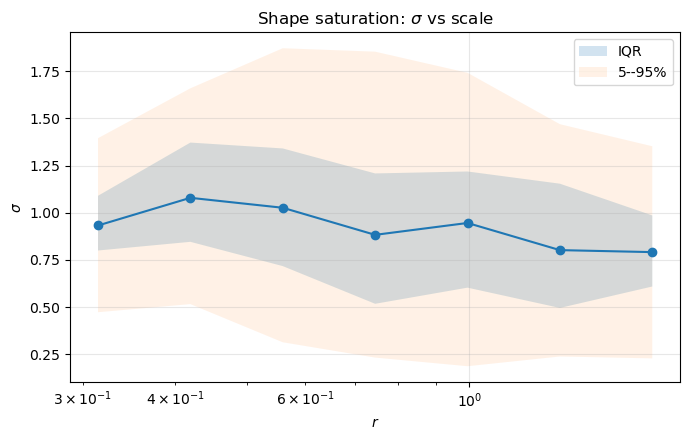

In [6]:
def sigma_stats(obs, bin_idx, n_bins):
    sig = obs['sigma'].ravel()
    means = np.full(n_bins, np.nan)
    sems = np.full(n_bins, np.nan)
    q05 = np.full(n_bins, np.nan); q25 = np.full(n_bins, np.nan)
    q50 = np.full(n_bins, np.nan); q75 = np.full(n_bins, np.nan); q95 = np.full(n_bins, np.nan)
    samples = []
    for k in range(n_bins):
        x = sig[bin_idx == k]
        samples.append(x)
        if len(x) < 10:
            continue
        means[k] = x.mean(); sems[k] = x.std() / np.sqrt(len(x))
        q05[k], q25[k], q50[k], q75[k], q95[k] = np.quantile(x, [0.05,0.25,0.5,0.75,0.95])
    return means, sems, (q05,q25,q50,q75,q95), samples

sigma_mean, sigma_sem, sigma_q, sigma_samples = sigma_stats(obs, bin_idx, n_bins)
print(f'{"bin":>4} {"r":>7} {"mean":>8} {"sem":>8} {"q25":>8} {"q50":>8} {"q75":>8}')
for k in range(n_bins):
    print(f'{k:>4d} {r_centers[k]:>7.3f} {sigma_mean[k]:>8.3f} {sigma_sem[k]:>8.3f} '
          f'{sigma_q[1][k]:>8.3f} {sigma_q[2][k]:>8.3f} {sigma_q[3][k]:>8.3f}')

ks_mat = np.full((n_bins, n_bins), np.nan)
for i in range(n_bins):
    for j in range(n_bins):
        if len(sigma_samples[i]) > 10 and len(sigma_samples[j]) > 10:
            ks_mat[i, j] = stats.ks_2samp(sigma_samples[i], sigma_samples[j]).statistic
print('\nPairwise KS distances for P(sigma | r):')
print(np.round(ks_mat, 3))

fig, ax = plt.subplots(1, 1, figsize=(7, 4.5))
ax.errorbar(r_centers, sigma_mean, yerr=sigma_sem, marker='o')
ax.fill_between(r_centers, sigma_q[1], sigma_q[3], alpha=0.2, label='IQR')
ax.fill_between(r_centers, sigma_q[0], sigma_q[4], alpha=0.1, label='5--95%')
ax.set_xscale('log')
ax.set_xlabel(r'$r$')
ax.set_ylabel(r'$\sigma$')
ax.set_title(r'Shape saturation: $\sigma$ vs scale')
ax.legend()
plt.tight_layout(); plt.show()


## 6. Strain--vorticity balance

The component-level ratio $\mathrm{var}(\omega)/\mathrm{var}(s_+)\approx 2$ is the 2D incompressible isotropic baseline.  The meaningful diagnostic is

$$
\chi(r)=\frac{\mathrm{var}(\tilde\omega)}{\mathrm{var}(\tilde s_+)+\mathrm{var}(\tilde s_\times)},
$$

with baseline $\chi=1$.

 bin       r     var_sp     var_sx     var_om      chi  component_ratio
   0   0.314    0.04704    0.03535     0.1199    1.455            2.910
   1   0.419    0.04333    0.04774    0.09978    1.096            2.191
   2   0.559    0.05244    0.04054    0.09367    1.007            2.015
   3   0.746    0.02965    0.05513     0.1084    1.279            2.558
   4   0.994    0.03012    0.03335    0.05871    0.925            1.850
   5   1.326    0.01717    0.02722    0.05802    1.307            2.614
   6   1.768    0.00882    0.02742    0.02813    0.776            1.553


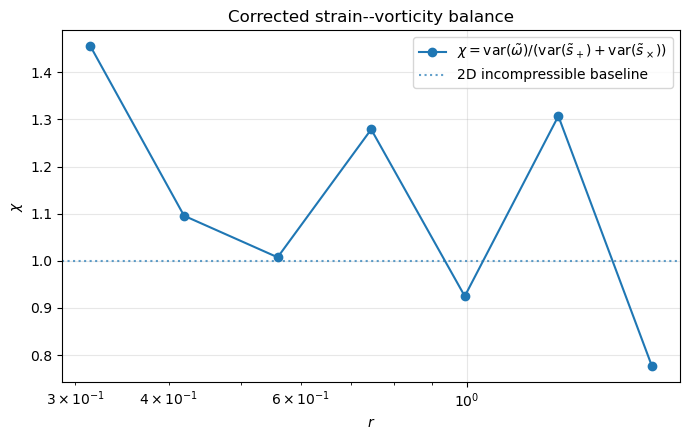

In [7]:
def chi_diagnostic(obs, bin_idx, n_bins, zeta=1/3):
    rfac = obs['r'].ravel() ** (1 - zeta)
    sp = obs['s_plus'].ravel() * rfac
    sx = obs['s_cross'].ravel() * rfac
    om = obs['omega'].ravel() * rfac
    var_sp = np.full(n_bins, np.nan); var_sx = np.full(n_bins, np.nan); var_om = np.full(n_bins, np.nan)
    chi = np.full(n_bins, np.nan)
    comp_ratio = np.full(n_bins, np.nan)
    for k in range(n_bins):
        sel = (bin_idx == k)
        if sel.sum() < 10:
            continue
        var_sp[k] = sp[sel].var()
        var_sx[k] = sx[sel].var()
        var_om[k] = om[sel].var()
        chi[k] = var_om[k] / (var_sp[k] + var_sx[k])
        comp_ratio[k] = var_om[k] / (0.5 * (var_sp[k] + var_sx[k]))
    return var_sp, var_sx, var_om, chi, comp_ratio

var_sp, var_sx, var_om, chi, comp_ratio = chi_diagnostic(obs, bin_idx, n_bins, zeta=zeta)
print(f'{"bin":>4} {"r":>7} {"var_sp":>10} {"var_sx":>10} {"var_om":>10} {"chi":>8} {"component_ratio":>16}')
for k in range(n_bins):
    print(f'{k:>4d} {r_centers[k]:>7.3f} {var_sp[k]:>10.4g} {var_sx[k]:>10.4g} {var_om[k]:>10.4g} '
          f'{chi[k]:>8.3f} {comp_ratio[k]:>16.3f}')

fig, ax = plt.subplots(1, 1, figsize=(7, 4.5))
ax.plot(r_centers, chi, marker='o', label=r'$\chi=\mathrm{var}(\tilde\omega)/(\mathrm{var}(\tilde s_+)+\mathrm{var}(\tilde s_\times))$')
ax.axhline(1.0, linestyle=':', alpha=0.7, label='2D incompressible baseline')
ax.set_xscale('log')
ax.set_xlabel(r'$r$')
ax.set_ylabel(r'$\chi$')
ax.set_title('Corrected strain--vorticity balance')
ax.legend()
plt.tight_layout(); plt.show()


## 7. $\langle |M|^2\rangle$ scaling

Fit the measured slope and compare it with the dimensional $-4/3$ reference.  A steeper slope should be reported as an empirical outcome, not forced to agree with dimensional scaling.

MEE + ellipsoid-averaged M: slope = -2.025 ± 0.114
Dimensional K41 reference: -1.333


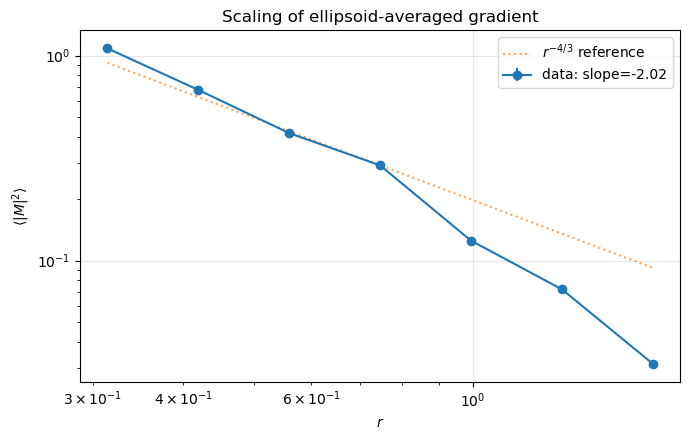

In [8]:
def M2_scaling(obs, bin_idx, n_bins):
    M2 = (obs['s_plus']**2 + obs['s_cross']**2 + obs['omega']**2).ravel()
    M2_mean = np.full(n_bins, np.nan); M2_sem = np.full(n_bins, np.nan)
    for k in range(n_bins):
        sel = (bin_idx == k)
        if sel.sum() < 5:
            continue
        M2_mean[k] = M2[sel].mean()
        M2_sem[k]  = M2[sel].std() / np.sqrt(sel.sum())
    return M2_mean, M2_sem


def fit_slope_M2(r_c, y, ye):
    valid = np.isfinite(y) & (y > 0) & np.isfinite(ye) & (ye > 0)
    if valid.sum() < 3:
        return np.nan, np.nan
    slope, _, _, _, se = stats.linregress(np.log(r_c[valid]), np.log(y[valid]))
    return slope, se

M2_mean, M2_sem = M2_scaling(obs, bin_idx, n_bins)
slope, se = fit_slope_M2(r_centers, M2_mean, M2_sem)
print(f'MEE + ellipsoid-averaged M: slope = {slope:.3f} ± {se:.3f}')
print(f'Dimensional K41 reference: {-4/3:.3f}')

fig, ax = plt.subplots(1, 1, figsize=(7, 4.5))
ax.errorbar(r_centers, M2_mean, yerr=M2_sem, marker='o', label=f'data: slope={slope:.2f}')
ref_idx = min(3, len(r_centers)-1)
ref_val = M2_mean[ref_idx]
ax.plot(r_centers, ref_val * (r_centers / r_centers[ref_idx]) ** (-4/3),
        linestyle=':', alpha=0.7, label=r'$r^{-4/3}$ reference')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$r$')
ax.set_ylabel(r'$\langle |M|^2 \rangle$')
ax.set_title(r'Scaling of ellipsoid-averaged gradient')
ax.legend()
plt.tight_layout(); plt.show()


## 8. Rescaled-component Gaussianity

Compute skewness and excess kurtosis of $(\tilde s_+,\tilde s_\times,\tilde\omega)$, where the tilde denotes multiplication by $r^{1-\zeta}$.

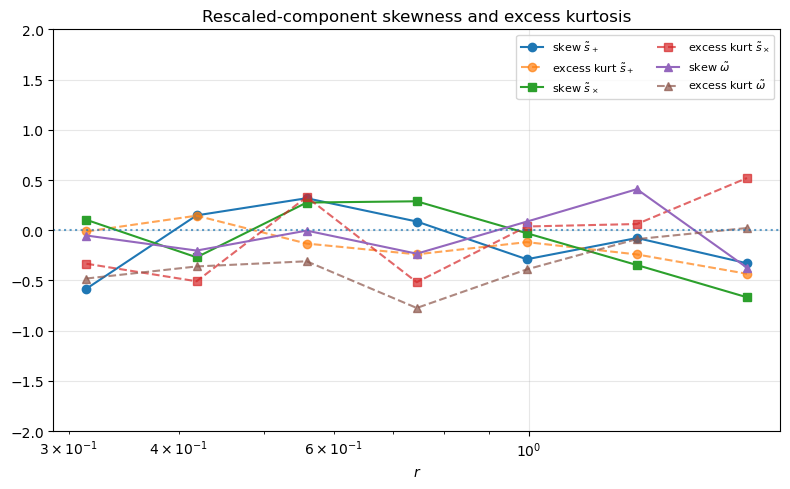

In [9]:
def skew_kurt(obs, bin_idx, n_bins, zeta=1/3):
    rfac = obs['r'].ravel() ** (1 - zeta)
    sp = obs['s_plus'].ravel() * rfac
    sx = obs['s_cross'].ravel() * rfac
    om = obs['omega'].ravel() * rfac
    sk = {'sp': np.full(n_bins, np.nan), 'sx': np.full(n_bins, np.nan), 'om': np.full(n_bins, np.nan)}
    kt = {'sp': np.full(n_bins, np.nan), 'sx': np.full(n_bins, np.nan), 'om': np.full(n_bins, np.nan)}
    for k in range(n_bins):
        sel = (bin_idx == k)
        if sel.sum() < 30:
            continue
        sk['sp'][k] = stats.skew(sp[sel]); kt['sp'][k] = stats.kurtosis(sp[sel])
        sk['sx'][k] = stats.skew(sx[sel]); kt['sx'][k] = stats.kurtosis(sx[sel])
        sk['om'][k] = stats.skew(om[sel]); kt['om'][k] = stats.kurtosis(om[sel])
    return sk, kt

sk, kt = skew_kurt(obs, bin_idx, n_bins, zeta=zeta)

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
for comp, lbl, mk in [('sp', r'$\tilde s_+$', 'o'), ('sx', r'$\tilde s_\times$', 's'), ('om', r'$\tilde\omega$', '^')]:
    ax.plot(r_centers, sk[comp], marker=mk, label=f'skew {lbl}')
    ax.plot(r_centers, kt[comp], marker=mk, linestyle='--', label=f'excess kurt {lbl}', alpha=0.7)
ax.axhline(0, linestyle=':', alpha=0.7)
ax.set_xscale('log')
ax.set_xlabel(r'$r$')
ax.set_title('Rescaled-component skewness and excess kurtosis')
ax.legend(ncol=2, fontsize=8)
ax.set_ylim(-2, 2)
plt.tight_layout(); plt.show()


## 9. Alignment and lifted-shape diagnostics

Use these as empirical constraints for the later generator model.  No reduced-model calibration is performed in this notebook.

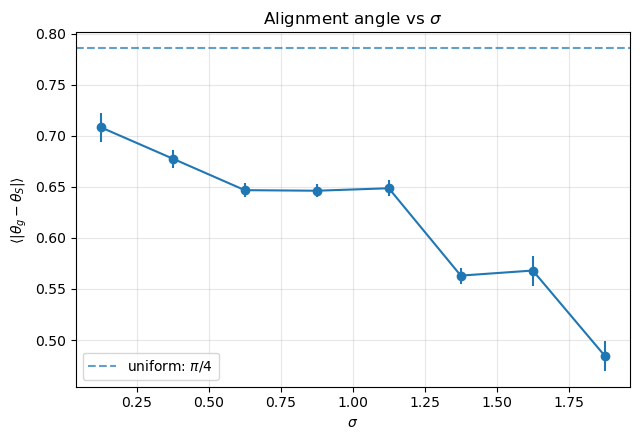

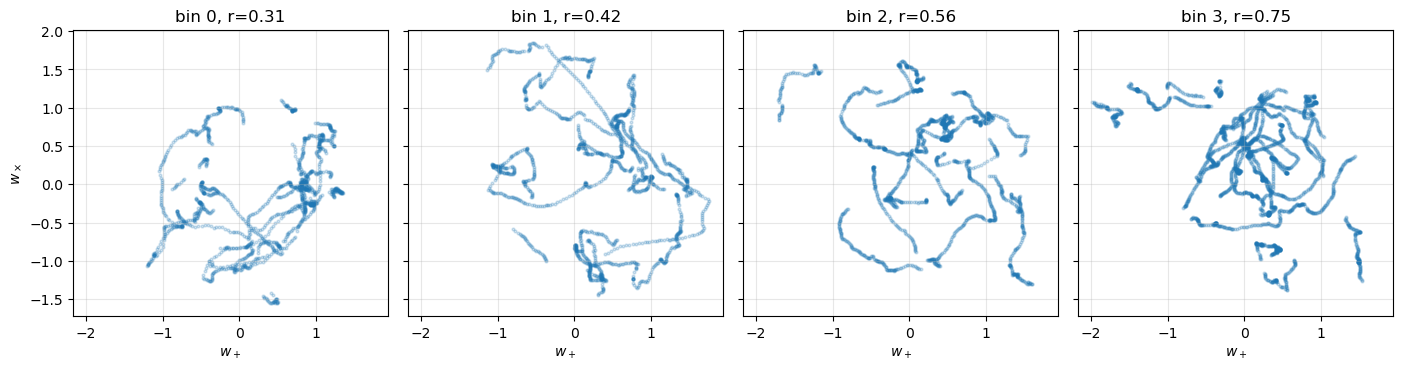

In [10]:
def angle_diff_mod_pi(a, b):
    return (a - b + PI/2) % PI - PI/2

# Alignment between ellipsoid axis and strain eigenvector
obs_use = obs
theta_diff = angle_diff_mod_pi(obs_use['theta_g'], obs_use['theta_S'])
abs_diff_flat = np.abs(theta_diff).ravel()
sigma_flat = obs_use['sigma'].ravel()
sigma_bins = np.linspace(0, 2.0, 9)
sigma_c = 0.5 * (sigma_bins[:-1] + sigma_bins[1:])
mean_d = np.full(len(sigma_c), np.nan)
sem_d  = np.full(len(sigma_c), np.nan)
for k in range(len(sigma_c)):
    sel = (sigma_flat >= sigma_bins[k]) & (sigma_flat < sigma_bins[k+1])
    if sel.sum() < 30:
        continue
    x = abs_diff_flat[sel]
    mean_d[k] = x.mean(); sem_d[k] = x.std() / np.sqrt(len(x))

fig, ax = plt.subplots(1, 1, figsize=(6.5, 4.5))
ax.errorbar(sigma_c, mean_d, yerr=sem_d, marker='o')
ax.axhline(PI/4, linestyle='--', alpha=0.7, label=r'uniform: $\pi/4$')
ax.set_xlabel(r'$\sigma$')
ax.set_ylabel(r'$\langle|\theta_g - \theta_S|\rangle$')
ax.set_title(r'Alignment angle vs $\sigma$')
ax.legend()
plt.tight_layout(); plt.show()

# Lifted shape coordinates by r-bin
w_plus = (obs['sigma'] * np.cos(2 * obs['theta_g'])).ravel()
w_cross = (obs['sigma'] * np.sin(2 * obs['theta_g'])).ravel()
fig, axes = plt.subplots(1, min(n_bins, 4), figsize=(14, 3.5), sharex=True, sharey=True)
for ax, k in zip(np.atleast_1d(axes), range(min(n_bins, 4))):
    sel = (bin_idx == k)
    ax.scatter(w_plus[sel], w_cross[sel], s=4, alpha=0.2)
    ax.set_title(f'bin {k}, r={r_centers[k]:.2f}')
    ax.set_xlabel(r'$w_+$')
    ax.set_aspect('equal', adjustable='box')
axes[0].set_ylabel(r'$w_\times$')
plt.tight_layout(); plt.show()


## 10. Empirical outputs for the next step

This notebook stops before SDE or neural-surrogate calibration.  The next notebook should use the arrays below for generator identification: short-time increments of $(v,\sigma,\theta,s_+,s_\times,\omega)$, conditioned on $r$ and optionally on $\sigma$.

In [11]:
# Package the primary empirical arrays for the next calibration stage.
empirical_train = {
    'times': all_times,
    'M': all_M,
    'g': all_g,
    'obs': obs,
    'r_edges': r_edges,
    'r_centers': r_centers,
    'bin_idx': bin_idx,
}

print('Prepared empirical_train with keys:', list(empirical_train.keys()))
print('Next stage: estimate conditional drifts/covariances of y=(v,sigma,theta,s_plus,s_cross,omega).')


Prepared empirical_train with keys: ['times', 'M', 'g', 'obs', 'r_edges', 'r_centers', 'bin_idx']
Next stage: estimate conditional drifts/covariances of y=(v,sigma,theta,s_plus,s_cross,omega).


In [12]:
np.savez_compressed(
    "empirical_train_mavg_out_v10.npz",
    times=all_times,
    M=all_M,
    g=all_g,
    r_edges=r_edges,
    r_centers=r_centers,
    bin_idx=bin_idx,
)

## 11. Summary

This cleaned empirical notebook answers only the questions relevant to the primary train:

1. Does the MEE shape saturate in mean and distribution?
2. What is the measured scaling of $\langle |M|^2\rangle$ for the ellipsoid-averaged gradient?
3. Is the corrected tensor-level strain--vorticity balance $\chi$ close to its incompressible baseline $1$?
4. How Gaussian are the rescaled gradient components?
5. What alignment and lifted-shape statistics should the later generator model reproduce?

No SDE calibration, lag analysis, or secondary-gradient comparison is performed here.